<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;max-width:1020px;padding:28px 0 34px;border-top:4px solid #146c7a;border-bottom:1px solid #dfe6e9">
  <div style="color:#146c7a;font-size:12px;font-weight:700;letter-spacing:.09em;text-transform:uppercase">Cuaderno de consulta y simulación</div>
  <h1 style="color:#18242a;font-size:36px;line-height:1.16;letter-spacing:-.025em;font-weight:650;margin:15px 0 17px">Matriz insumo-producto de Guatemala 2013</h1>
  <div style="color:#58666d;font-size:16px;line-height:1.55;max-width:860px">Visor didáctico para comprender la estructura productiva, explorar multiplicadores y simular choques de demanda final con los CSV publicados.</div>
  <div style="display:flex;flex-wrap:wrap;gap:8px 18px;margin-top:25px;color:#69767d;font-size:13px"><strong style="color:#334148;font-weight:600">Juan Alejandro Osorio</strong><span>152 productos</span><span>Precios básicos</span><span>Año de referencia 2013</span></div>
  <div style="margin-top:14px"><a href="https://colab.research.google.com/github/JA-Osorio/mip-guatemala-2013-reproducible/blob/main/04_reproduccion_python/cuaderno_exploracion_mip_2013.ipynb"><img alt="Abrir en Colab" src="https://colab.research.google.com/assets/colab-badge.svg"></a></div>
</div>

Este cuaderno funciona como un libro interactivo. Lee exclusivamente los CSV finales publicados: no necesita ni vuelve a procesar el archivo fuente original.

<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;display:flex;flex-wrap:wrap;gap:8px;margin:18px 0 4px">
<a href="#panorama" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">1 · Panorama y QA</a>
<a href="#estructura" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">2 · Estructura</a>
<a href="#explorador" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">3 · Producto</a>
<a href="#encadenamientos" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">4 · Multiplicadores</a>
<a href="#intensidades" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">5 · Intensidades</a>
<a href="#simulador" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">6 · Simulador</a>
<a href="#descargas" style="text-decoration:none;border:1px solid #cfdadd;border-radius:18px;padding:7px 12px;color:#146c7a">7 · Descargas y guía</a>
</div>

**Ruta sugerida.** Revise primero los controles, use el explorador para comprender un producto y después interprete el simulador. Las importaciones son fugas intermedias del circuito doméstico; el empleo es una asociación lineal con coeficientes medios de 2013, no una predicción de empleo neto.

In [1]:
#@title { display-mode: "form" }
from __future__ import annotations

import base64
import html as _html
import io
import os
from pathlib import Path
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=DeprecationWarning)

REPO_URL = "https://github.com/JA-Osorio/mip-guatemala-2013-reproducible.git"
try:
    import google.colab  # type: ignore
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB:
    ROOT = Path("/content/mip-guatemala-2013-reproducible")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(ROOT)], check=True)
else:
    candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    ROOT = next(
        (ruta.resolve() for ruta in candidatos if (ruta / "02_resultados_y_diccionario").is_dir()),
        None,
    )
    if ROOT is None:
        raise FileNotFoundError(
            "Ejecute el cuaderno desde la raíz del repositorio o ábralo en Google Colab."
        )

try:
    import plotly.graph_objects as go
    import plotly.io as pio
    from plotly.subplots import make_subplots
    import ipywidgets as widgets
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "plotly>=5,<7", "ipywidgets>=8,<9"],
        check=True,
    )
    import plotly.graph_objects as go
    import plotly.io as pio
    from plotly.subplots import make_subplots
    import ipywidgets as widgets

from IPython.display import HTML, clear_output, display

try:
    import kaleido  # noqa: F401
    pio.renderers.default = "notebook_connected+svg"
except ImportError:
    pio.renderers.default = "notebook_connected"

if EN_COLAB:
    try:
        from google.colab import output as _colab_output
        _colab_output.enable_custom_widget_manager()
    except Exception:
        pass

RESULTADOS = ROOT / "02_resultados_y_diccionario"
VERIFICACION = ROOT / "05_verificacion"

def leer_matriz(nombre):
    marco = pd.read_csv(RESULTADOS / "matrices" / nombre)
    metadatos = marco[["codigo", "producto"]].copy()
    valores = marco.iloc[:, 2:].to_numpy(float)
    if tuple(metadatos["codigo"]) != tuple(marco.columns[2:]):
        raise ValueError(f"Filas y columnas no coinciden en {nombre}")
    return metadatos, valores

productos = pd.read_csv(RESULTADOS / "productos_2013.csv")
meta_matriz, Z_d = leer_matriz("Z_domestica_2013.csv")
_, Z_m = leer_matriz("Z_importada_2013.csv")
_, A_d = leer_matriz("A_domestica_2013.csv")
_, A_m = leer_matriz("A_importada_2013.csv")
_, A_t = leer_matriz("A_total_insumos_2013.csv")
_, L_d = leer_matriz("Leontief_domestica_2013.csv")
primarios = pd.read_csv(RESULTADOS / "vectores" / "coeficientes_primarios_2013.csv")
produccion = pd.read_csv(RESULTADOS / "vectores" / "produccion_y_utilizacion_2013.csv")
indicadores_publicados = pd.read_csv(RESULTADOS / "indicadores_io_2013.csv")
balances = pd.read_csv(VERIFICACION / "balances_por_producto.csv")
controles_publicados = pd.read_csv(VERIFICACION / "controles_reproduccion.csv")

CODIGOS = tuple(productos["codigo"])
ETIQUETAS = dict(zip(productos["codigo"], productos["producto"]))
N = len(CODIGOS)
if N != 152:
    raise ValueError(f"Se esperaban 152 productos y se encontraron {N}.")
for marco in (meta_matriz, primarios, produccion, indicadores_publicados, balances):
    if tuple(marco["codigo"]) != CODIGOS:
        raise ValueError("Los CSV no comparten el mismo orden de productos.")

x = produccion["produccion_precios_basicos"].to_numpy(float)
u = produccion["total_utilizacion_precios_basicos"].to_numpy(float)
puestos = produccion["puestos_trabajo"].to_numpy(float)
v = primarios["valor_agregado_bruto"].to_numpy(float)
e = np.divide(puestos, x, out=np.zeros_like(puestos), where=x > 0)
CODIGOS_PRODUCCION_CERO = tuple(codigo for codigo, valor in zip(CODIGOS, x) if valor <= 0)
CODIGOS_SIMULABLES = tuple(codigo for codigo, valor in zip(CODIGOS, x) if valor > 0)
unos = np.ones(N)

multiplicador_produccion = L_d.sum(axis=0)
enc_atras = multiplicador_produccion / multiplicador_produccion.mean()
enc_adelante_bruto = L_d.sum(axis=1)
enc_adelante = enc_adelante_bruto / enc_adelante_bruto.mean()
coef_importacion_directa = A_m.sum(axis=0)
requerimiento_importacion_total = (A_m @ L_d).sum(axis=0)
multiplicador_va = v @ L_d
multiplicador_empleo = e @ L_d

indicadores = pd.DataFrame({
    "codigo": CODIGOS,
    "producto": [ETIQUETAS[c] for c in CODIGOS],
    "multiplicador_produccion_domestica": multiplicador_produccion,
    "encadenamiento_atras_normalizado": enc_atras,
    "encadenamiento_adelante_normalizado": enc_adelante,
    "coeficiente_importacion_directa": coef_importacion_directa,
    "requerimiento_importacion_total": requerimiento_importacion_total,
    "multiplicador_valor_agregado": multiplicador_va,
    "multiplicador_empleo_puestos_por_millon": multiplicador_empleo,
    "produccion_millones_q": x,
    "utilizacion_millones_q": u,
})
indicadores["tipo_encadenamiento"] = np.select(
    [
        (indicadores["encadenamiento_atras_normalizado"] >= 1)
        & (indicadores["encadenamiento_adelante_normalizado"] >= 1),
        (indicadores["encadenamiento_atras_normalizado"] >= 1)
        & (indicadores["encadenamiento_adelante_normalizado"] < 1),
        (indicadores["encadenamiento_atras_normalizado"] < 1)
        & (indicadores["encadenamiento_adelante_normalizado"] >= 1),
    ],
    ["Clave", "Impulsor", "Dispersor"],
    default="Independiente",
)

columnas_io = list(indicadores_publicados.columns[2:])
diferencia_indicadores = float(
    np.max(
        np.abs(
            indicadores[columnas_io].to_numpy(float)
            - indicadores_publicados[columnas_io].to_numpy(float)
        )
    )
)
residuo_inversa = float(np.max(np.abs((np.eye(N) - A_d) @ L_d - np.eye(N))))
residuo_descomposicion = float(np.max(np.abs(A_t - A_d - A_m)))
residuo_balance_final = float(
    max(
        balances["balance_fila_ajustado"].abs().max(),
        balances["balance_columna"].abs().max(),
    )
)
controles_obligatorios = controles_publicados[
    controles_publicados["mandatory"].astype(str).str.lower().eq("true")
]
controles_aprobados = int(controles_obligatorios["status"].eq("APROBADO").sum())

qa_resumen = pd.DataFrame([
    ["Productos y orden NPG", N, 152, N == 152],
    ["Inversa doméstica: residuo máximo", residuo_inversa, "<= 1e-10", residuo_inversa <= 1e-10],
    ["A total = A doméstica + A importada", residuo_descomposicion, "<= 1e-12", residuo_descomposicion <= 1e-12],
    ["Balance final: residuo máximo", residuo_balance_final, "<= 1e-10", residuo_balance_final <= 1e-10],
    ["Indicadores recalculados vs publicados", diferencia_indicadores, "<= 1e-12", diferencia_indicadores <= 1e-12],
    ["Controles obligatorios aprobados", controles_aprobados, len(controles_obligatorios), controles_aprobados == len(controles_obligatorios)],
], columns=["control", "valor", "tolerancia", "cumple"])

if not qa_resumen["cumple"].all():
    raise AssertionError("Falló al menos un control del cuaderno.")

CSS = """
<style>
.mip-wrap{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;color:#29373d;max-width:1120px}
.mip-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(178px,1fr));gap:10px;margin:12px 0 18px}
.mip-card{border:1px solid #dfe6e9;border-radius:10px;background:#fff;padding:15px 16px;min-height:90px;box-shadow:0 1px 0 rgba(24,36,42,.03)}
.mip-card .k{color:#718087;font-size:11px;font-weight:700;letter-spacing:.05em;text-transform:uppercase}
.mip-card .v{color:#18242a;font-size:25px;font-weight:650;letter-spacing:-.02em;margin-top:8px;font-variant-numeric:tabular-nums}
.mip-card .n{color:#7c898f;font-size:11px;line-height:1.35;margin-top:5px}
.mip-table-wrap{border:1px solid #dfe6e9;border-radius:9px;overflow:auto;max-height:560px;background:#fff;margin:10px 0 16px}
.mip-table{border-collapse:separate;border-spacing:0;width:100%;min-width:650px;font-size:12px;line-height:1.35;font-variant-numeric:tabular-nums}
.mip-table th,.mip-table td{padding:9px 10px;border-bottom:1px solid #e9edef;text-align:right}
.mip-table thead th{position:sticky;top:0;background:#f5f8f9;color:#45535a;font-weight:650;z-index:2}
.mip-table th:first-child,.mip-table td:first-child,.mip-table th:nth-child(2),.mip-table td:nth-child(2){text-align:left}
.mip-table tbody tr:hover{background:#fafdfd}
.mip-table .ok{color:#1f735d;font-weight:650}.mip-table .bad{color:#a3473c;font-weight:650}
.mip-note{border-left:3px solid #6aa6ad;background:#f5f9f9;padding:11px 13px;margin:10px 0 16px;color:#56666d;font-size:12px;line-height:1.5}
.mip-links{display:flex;flex-wrap:wrap;gap:8px;margin:10px 0 18px}
.mip-btn{display:inline-block;text-decoration:none;border:1px solid #bfcfd3;border-radius:19px;padding:8px 12px;color:#146c7a;background:#fff;font-size:12px;font-weight:600}
.mip-btn:hover{background:#f3f8f8}
.mip-two{display:grid;grid-template-columns:repeat(auto-fit,minmax(360px,1fr));gap:14px}
</style>
"""
display(HTML(CSS))

def fmt_num(valor, decimales=2):
    if valor is None or (isinstance(valor, float) and np.isnan(valor)):
        return "—"
    return f"{float(valor):,.{decimales}f}"

def tarjetas(items):
    bloques = []
    for etiqueta, valor, nota in items:
        bloques.append(
            '<div class="mip-card">'
            f'<div class="k">{_html.escape(str(etiqueta))}</div>'
            f'<div class="v">{_html.escape(str(valor))}</div>'
            f'<div class="n">{_html.escape(str(nota))}</div></div>'
        )
    return HTML('<div class="mip-wrap"><div class="mip-grid">' + "".join(bloques) + "</div></div>")

def tabla_ligera(marco, columnas=None, nombres=None, formatos=None, max_filas=15):
    tabla = marco.copy()
    if columnas is not None:
        tabla = tabla[list(columnas)]
    tabla = tabla.head(max_filas)
    nombres = nombres or {}
    formatos = formatos or {}
    encabezado = "".join(
        f"<th>{_html.escape(str(nombres.get(col, col)))}</th>" for col in tabla.columns
    )
    filas = []
    for _, fila in tabla.iterrows():
        celdas = []
        for col in tabla.columns:
            valor = fila[col]
            if col in formatos:
                texto = formatos[col](valor)
            elif isinstance(valor, (float, np.floating)):
                texto = fmt_num(valor, 4)
            else:
                texto = str(valor)
            clase = ""
            if col == "cumple":
                clase = ' class="ok"' if bool(valor) else ' class="bad"'
                texto = "APROBADO" if bool(valor) else "REVISAR"
            celdas.append(f"<td{clase}>{_html.escape(texto)}</td>")
        filas.append("<tr>" + "".join(celdas) + "</tr>")
    return HTML(
        '<div class="mip-wrap"><div class="mip-table-wrap"><table class="mip-table">'
        f"<thead><tr>{encabezado}</tr></thead><tbody>{''.join(filas)}</tbody>"
        "</table></div></div>"
    )

COLORES = {
    "domestico": "#146c7a",
    "importado": "#d9985f",
    "acento": "#6aa6ad",
    "oscuro": "#263a42",
    "gris": "#9aa7ac",
}

def estilo_figura(fig, titulo, altura=520, margen_izq=80):
    fig.update_layout(
        title={"text": titulo, "x": 0.01, "xanchor": "left", "font": {"size": 17}},
        template="plotly_white",
        height=altura,
        margin={"l": margen_izq, "r": 25, "t": 70, "b": 55},
        font={"family": "Arial, Helvetica, sans-serif", "size": 12, "color": "#334148"},
        hoverlabel={"font": {"family": "Arial, Helvetica, sans-serif"}},
        legend={"orientation": "h", "y": 1.02, "x": 1, "xanchor": "right", "yanchor": "bottom"},
    )
    fig.update_xaxes(showgrid=True, gridcolor="#edf1f2", zeroline=False)
    fig.update_yaxes(showgrid=False, zeroline=False)
    return fig

def mostrar_figura(fig):
    display(fig)

def indice_codigo(codigo):
    return CODIGOS.index(codigo)

def vista_producto(codigo, mostrar=True):
    j = indice_codigo(codigo)
    fila = indicadores.iloc[j]
    if mostrar and x[j] <= 0:
        display(HTML(
            '<div class="mip-note"><strong>Producción base cero.</strong> '
            'Este producto no tiene coeficientes productivos observados. La diagonal unitaria de L '
            'es una identidad algebraica, no una estimación sustantiva; por eso no está habilitado '
            'en el simulador.</div>'
        ))
    tarjetas_producto = tarjetas([
        ("Producción", f"Q {fmt_num(x[j], 2)} M", "precios básicos de 2013"),
        ("Uso total", f"Q {fmt_num(u[j], 2)} M", "utilización total"),
        ("Multiplicador", fmt_num(fila["multiplicador_produccion_domestica"], 3), "producción doméstica por Q1 M"),
        ("Importación total", fmt_num(fila["requerimiento_importacion_total"], 3), "requerimiento intermedio por Q1 M"),
        ("Valor agregado", fmt_num(fila["multiplicador_valor_agregado"], 3), "VAB por Q1 M"),
        ("Empleo asociado", fmt_num(fila["multiplicador_empleo_puestos_por_millon"], 2), "puestos por Q1 M"),
    ])
    proveedores = pd.DataFrame({
        "codigo": CODIGOS,
        "producto": [ETIQUETAS[c] for c in CODIGOS],
        "domestico": A_d[:, j],
        "importado": A_m[:, j],
    })
    proveedores["total"] = proveedores["domestico"] + proveedores["importado"]
    proveedores = proveedores.nlargest(12, "total").sort_values("total")
    fig = go.Figure()
    fig.add_bar(
        y=proveedores["codigo"], x=proveedores["domestico"], name="Doméstico",
        orientation="h", marker_color=COLORES["domestico"],
        customdata=proveedores[["producto"]],
        hovertemplate="<b>%{customdata[0]}</b><br>Coeficiente: %{x:.4f}<extra>Doméstico</extra>",
    )
    fig.add_bar(
        y=proveedores["codigo"], x=proveedores["importado"], name="Importado",
        orientation="h", marker_color=COLORES["importado"],
        customdata=proveedores[["producto"]],
        hovertemplate="<b>%{customdata[0]}</b><br>Coeficiente: %{x:.4f}<extra>Importado</extra>",
    )
    fig.update_layout(barmode="stack")
    estilo_figura(
        fig,
        f"Principales insumos directos · {codigo} — {ETIQUETAS[codigo]}",
        altura=500,
        margen_izq=65,
    )
    respuesta = pd.DataFrame({
        "codigo": CODIGOS,
        "producto": [ETIQUETAS[c] for c in CODIGOS],
        "produccion_por_q1m": L_d[:, j],
    }).nlargest(10, "produccion_por_q1m")
    if mostrar:
        display(tarjetas_producto)
        mostrar_figura(fig)
        display(
            tabla_ligera(
                respuesta,
                columnas=["codigo", "producto", "produccion_por_q1m"],
                nombres={"produccion_por_q1m": "Producción por Q1 M"},
                formatos={"produccion_por_q1m": lambda z: fmt_num(z, 4)},
                max_filas=10,
            )
        )
    return tarjetas_producto, fig, respuesta

def simular(codigo, monto):
    j = indice_codigo(codigo)
    if x[j] <= 0:
        raise ValueError(
            f"{codigo} tiene producción base cero; no posee coeficientes productivos observados y no es simulable."
        )
    choque = np.zeros(N)
    choque[j] = float(monto)
    delta_x = L_d @ choque
    delta_m = A_m @ delta_x
    delta_va = v * delta_x
    delta_e = e * delta_x
    detalle = pd.DataFrame({
        "codigo": CODIGOS,
        "producto": [ETIQUETAS[c] for c in CODIGOS],
        "produccion_millones_q": delta_x,
        "importaciones_millones_q": delta_m,
        "valor_agregado_millones_q": delta_va,
        "puestos_trabajo_asociados": delta_e,
    }).sort_values("produccion_millones_q", ascending=False)
    resumen = {
        "producto": ETIQUETAS[codigo],
        "codigo": codigo,
        "demanda_final_millones_q": float(monto),
        "produccion_domestica_millones_q": float(delta_x.sum()),
        "importaciones_intermedias_millones_q": float(delta_m.sum()),
        "valor_agregado_millones_q": float(delta_va.sum()),
        "puestos_trabajo_asociados": float(delta_e.sum()),
    }
    return resumen, detalle

def vista_simulacion(codigo, monto, mostrar=True):
    resumen, detalle = simular(codigo, monto)
    panel = tarjetas([
        ("Choque de demanda", f"Q {fmt_num(monto, 2)} M", f"{codigo} · {ETIQUETAS[codigo]}"),
        ("Producción doméstica", f"Q {fmt_num(resumen['produccion_domestica_millones_q'], 2)} M", "directa e indirecta"),
        ("Importaciones", f"Q {fmt_num(resumen['importaciones_intermedias_millones_q'], 2)} M", "insumos intermedios"),
        ("Valor agregado", f"Q {fmt_num(resumen['valor_agregado_millones_q'], 2)} M", "asociado al cambio de producción"),
        ("Empleo asociado", fmt_num(resumen["puestos_trabajo_asociados"], 2), "puestos según coeficientes medios"),
    ])
    top = detalle.head(12).sort_values("produccion_millones_q")
    fig = go.Figure(
        go.Bar(
            y=top["codigo"], x=top["produccion_millones_q"], orientation="h",
            marker_color=COLORES["domestico"],
            customdata=top[["producto"]],
            hovertemplate="<b>%{customdata[0]}</b><br>Q %{x:.4f} millones<extra></extra>",
        )
    )
    estilo_figura(fig, "Productos con mayor respuesta de producción", altura=500, margen_izq=65)
    if mostrar:
        display(panel)
        mostrar_figura(fig)
        display(
            tabla_ligera(
                detalle,
                columnas=[
                    "codigo", "producto", "produccion_millones_q",
                    "importaciones_millones_q", "valor_agregado_millones_q",
                    "puestos_trabajo_asociados",
                ],
                nombres={
                    "produccion_millones_q": "Producción Q M",
                    "importaciones_millones_q": "Importaciones Q M",
                    "valor_agregado_millones_q": "VAB Q M",
                    "puestos_trabajo_asociados": "Puestos",
                },
                formatos={
                    "produccion_millones_q": lambda z: fmt_num(z, 4),
                    "importaciones_millones_q": lambda z: fmt_num(z, 4),
                    "valor_agregado_millones_q": lambda z: fmt_num(z, 4),
                    "puestos_trabajo_asociados": lambda z: fmt_num(z, 3),
                },
                max_filas=12,
            )
        )
    return resumen, detalle, panel, fig

def enlace_descarga_csv(marco, nombre, etiqueta):
    contenido = marco.to_csv(index=False).encode("utf-8")
    dato = base64.b64encode(contenido).decode("ascii")
    return (
        f'<a class="mip-btn" download="{_html.escape(nombre)}" '
        f'href="data:text/csv;base64,{dato}">{_html.escape(etiqueta)}</a>'
    )

display(
    HTML(
        '<div class="mip-note">Datos cargados y verificados desde '
        '<strong>02_resultados_y_diccionario</strong> y <strong>05_verificacion</strong>. '
        'No se consultó el archivo fuente original.</div>'
    )
)

<a id="panorama"></a>
## 1. Panorama de la MIP y controles de calidad

La MIP producto por producto registra transacciones domésticas e importadas en millones de quetzales a precios básicos de 2013. Las tarjetas dimensionan el sistema; la tabla prueba que matrices, balances e indicadores publicados son coherentes.

In [2]:
#@title { display-mode: "form" }
total_intermedio = float(Z_d.sum() + Z_m.sum())
participacion_domestica = float(Z_d.sum() / total_intermedio)
display(
    tarjetas([
        ("Productos", f"{N}", "clasificación NPG P001–P152"),
        ("Producción total", f"Q {fmt_num(x.sum(), 0)} M", "precios básicos de 2013"),
        ("Valor agregado", f"Q {fmt_num((v * x).sum(), 0)} M", "suma asociada a la producción"),
        ("Puestos de trabajo", fmt_num(puestos.sum(), 0), "registro publicado"),
        ("Insumos domésticos", f"{participacion_domestica:.1%}", "del consumo intermedio monetario"),
        ("QA obligatorio", f"{controles_aprobados}/{len(controles_obligatorios)}", "controles aprobados"),
    ])
)
display(
    tabla_ligera(
        qa_resumen,
        nombres={"control": "Control", "valor": "Valor", "tolerancia": "Tolerancia", "cumple": "Estado"},
        formatos={"valor": lambda z: fmt_num(z, 3) if isinstance(z, (float, np.floating)) else str(z)},
        max_filas=10,
    )
)
ajustes_mayores = balances.assign(
    magnitud_preajuste=balances["diferencia_produccion_utilizacion"].abs()
).nlargest(6, "magnitud_preajuste")
display(HTML('<div class="mip-note"><strong>Mayores diferencias antes del ajuste de balance.</strong> El balance final publicado es cero dentro de tolerancia; esta vista hace visibles los ajustes, no los oculta.</div>'))
display(
    tabla_ligera(
        ajustes_mayores,
        columnas=["codigo", "producto", "diferencia_produccion_utilizacion", "balance_fila_ajustado", "balance_columna"],
        nombres={
            "diferencia_produccion_utilizacion": "Diferencia previa",
            "balance_fila_ajustado": "Balance fila final",
            "balance_columna": "Balance columna",
        },
        formatos={
            "diferencia_produccion_utilizacion": lambda z: fmt_num(z, 8),
            "balance_fila_ajustado": lambda z: fmt_num(z, 12),
            "balance_columna": lambda z: fmt_num(z, 12),
        },
        max_filas=6,
    )
)

Control,Valor,Tolerancia,Estado
Productos y orden NPG,152.000,152,APROBADO
Inversa doméstica: residuo máximo,0.000,<= 1e-10,APROBADO
A total = A doméstica + A importada,0.000,<= 1e-12,APROBADO
Balance final: residuo máximo,0.000,<= 1e-10,APROBADO
Indicadores recalculados vs publicados,0.000,<= 1e-12,APROBADO
Controles obligatorios aprobados,21.000,21,APROBADO


codigo,producto,Diferencia previa,Balance fila final,Balance columna
P105,Servicio de transporte de carga por vía terrestre,0.18999999,0.000000000000,0.000000000000
P099,Edificaciones no residenciales,-0.16331087,0.000000000000,0.000000000000
P123,"Otros servicios profesionales, científicos y técnicos",-0.02500000,0.000000000000,0.000000000000
P005,Otros cereales,-0.00000312,0.000000000000,0.000000000000
P106,Otros tipos de transporte,0.00000044,0.000000000000,0.000000000000
P010,Caña de azúcar y otras plantas azucareras,0.00000012,0.000000000000,0.000000000000


<a id="estructura"></a>
## 2. Estructura doméstica e importada

Cada columna representa la estructura de insumos del producto que se produce. El gráfico apilado compara el valor de insumos domésticos e importados; el mapa de calor muestra coeficientes técnicos para los 35 productos con mayor producción.

\[
A^d=Z^d\widehat{x}^{-1},\qquad A^m=Z^m\widehat{x}^{-1},\qquad A^t=A^d+A^m
\]

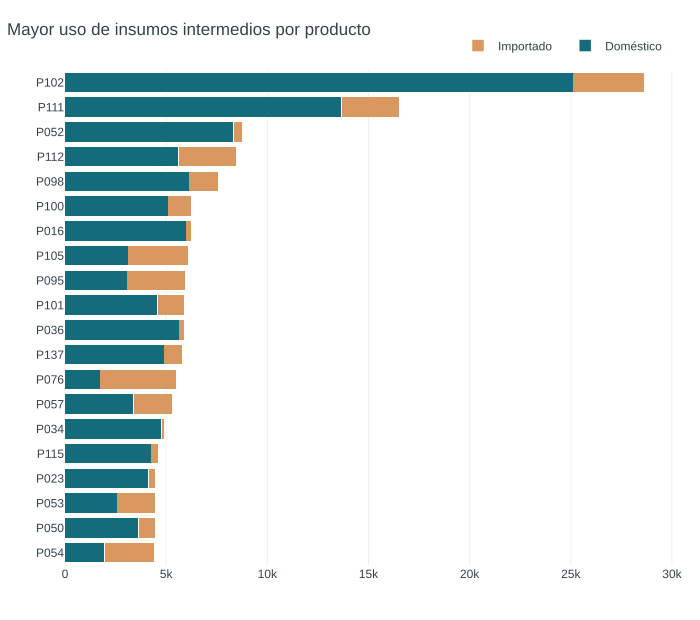

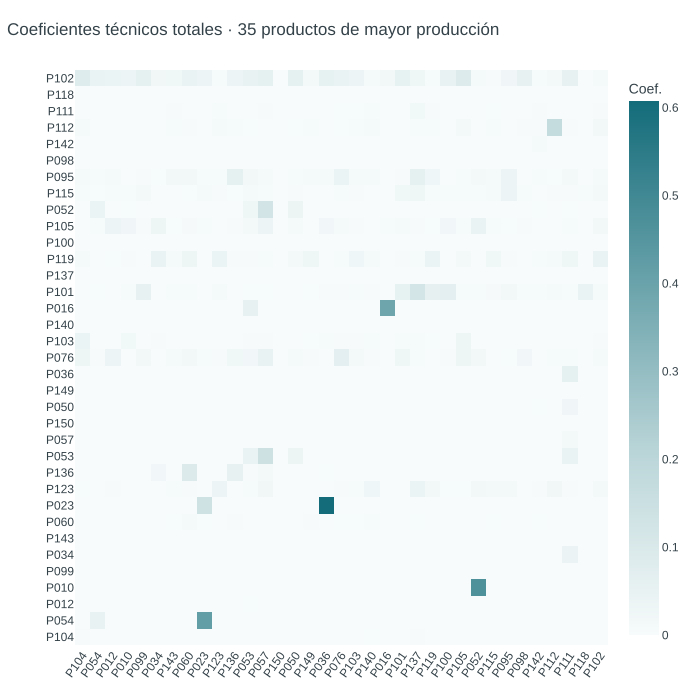

In [3]:
#@title { display-mode: "form" }
uso_domestico_producto = Z_d.sum(axis=0)
uso_importado_producto = Z_m.sum(axis=0)
estructura = pd.DataFrame({
    "codigo": CODIGOS,
    "producto": [ETIQUETAS[c] for c in CODIGOS],
    "domestico": uso_domestico_producto,
    "importado": uso_importado_producto,
})
estructura["total"] = estructura["domestico"] + estructura["importado"]
top_estructura = estructura.nlargest(20, "total").sort_values("total")

display(
    tarjetas([
        ("Intermedio doméstico", f"Q {fmt_num(Z_d.sum(), 0)} M", "transacciones nacionales"),
        ("Intermedio importado", f"Q {fmt_num(Z_m.sum(), 0)} M", "insumos importados"),
        ("Participación importada", f"{Z_m.sum() / total_intermedio:.1%}", "del consumo intermedio"),
        ("Descomposición A", f"{residuo_descomposicion:.2e}", "residuo máximo"),
    ])
)

fig_estructura = go.Figure()
fig_estructura.add_bar(
    y=top_estructura["codigo"], x=top_estructura["domestico"], orientation="h",
    name="Doméstico", marker_color=COLORES["domestico"],
    customdata=top_estructura[["producto"]],
    hovertemplate="<b>%{customdata[0]}</b><br>Q %{x:,.2f} millones<extra>Doméstico</extra>",
)
fig_estructura.add_bar(
    y=top_estructura["codigo"], x=top_estructura["importado"], orientation="h",
    name="Importado", marker_color=COLORES["importado"],
    customdata=top_estructura[["producto"]],
    hovertemplate="<b>%{customdata[0]}</b><br>Q %{x:,.2f} millones<extra>Importado</extra>",
)
fig_estructura.update_layout(barmode="stack")
estilo_figura(fig_estructura, "Mayor uso de insumos intermedios por producto", altura=620, margen_izq=65)
mostrar_figura(fig_estructura)

idx_calor = np.argsort(x)[-35:]
codigos_calor = [CODIGOS[i] for i in idx_calor]
z_calor = A_t[np.ix_(idx_calor, idx_calor)]
fig_calor = go.Figure(
    go.Heatmap(
        z=z_calor,
        x=codigos_calor,
        y=codigos_calor,
        colorscale=[[0, "#f7fbfb"], [0.35, "#b8d4d7"], [1, "#146c7a"]],
        colorbar={"title": "Coef."},
        hovertemplate="Insumo %{y} → producto %{x}<br>Coeficiente %{z:.5f}<extra></extra>",
    )
)
estilo_figura(fig_calor, "Coeficientes técnicos totales · 35 productos de mayor producción", altura=700, margen_izq=75)
fig_calor.update_xaxes(tickangle=-55)
mostrar_figura(fig_calor)

<a id="explorador"></a>
## 3. Explorador por producto

La vista inicial corresponde a **P102 · Servicios de comercio**. El selector permite recorrer los 152 productos. Los insumos directos provienen de las columnas de \(A^d\) y \(A^m\); la respuesta a Q1 millón de demanda final corresponde a la columna del producto en \(L^d\).

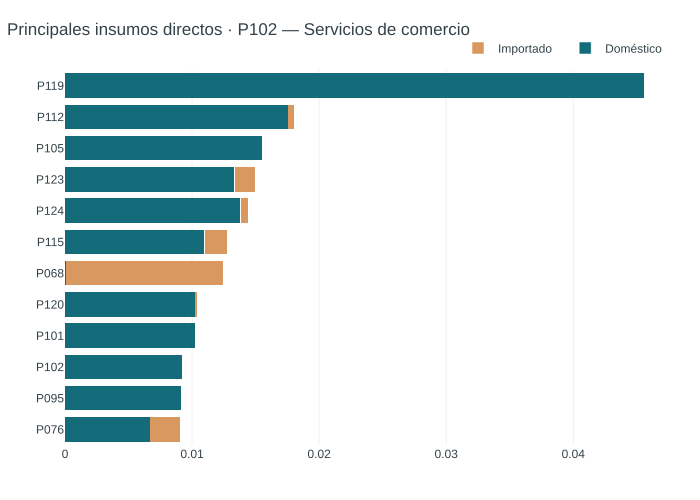

codigo,producto,Producción por Q1 M
P102,Servicios de comercio,1.0183
P119,"Otros servicios inmobiliarios, excepto alquiler de vivienda",0.0531
P112,"Servicios de información, telecomunicaciones y radiodifusión",0.0227
P123,"Otros servicios profesionales, científicos y técnicos",0.0183
P105,Servicio de transporte de carga por vía terrestre,0.0179
P124,Servicios de publicidad y estudios de mercado,0.0167
P101,Servicios generales y especializados de construcción,0.0164
P095,"Generación y distribución de energía eléctrica, gas, vapor y aire acondicionado",0.0142
P120,"Servicios jurídicos, de contabilidad, auditoría, teneduría de libros y consultoría fiscal",0.0137
P115,Servicios de Intermediación Financiera Medidos Indirectamente (SIFMI),0.0134


Dropdown(description='Producto', index=101, layout=Layout(width='760px'), options=(('P001 · Maíz', 'P001'), ('…

Output()

In [4]:
#@title { display-mode: "form" }
PRODUCTO_INICIAL = "P102"
display(HTML('<div class="mip-note"><strong>Vista almacenada.</strong> P102 · Servicios de comercio. Use el selector siguiente para otra consulta.</div>'))
vista_producto(PRODUCTO_INICIAL)

selector_producto = widgets.Dropdown(
    options=[(f"{codigo} · {ETIQUETAS[codigo]}", codigo) for codigo in CODIGOS],
    value=PRODUCTO_INICIAL,
    description="Producto",
    layout=widgets.Layout(width="760px"),
    style={"description_width": "70px"},
)
salida_producto = widgets.Output()

def actualizar_producto(cambio=None):
    with salida_producto:
        clear_output(wait=True)
        vista_producto(selector_producto.value)

selector_producto.observe(actualizar_producto, names="value")
display(HTML('<div class="mip-note"><strong>Explorador interactivo.</strong> La salida cambia al elegir otro producto.</div>'))
display(selector_producto, salida_producto)

<a id="encadenamientos"></a>
## 4. Multiplicadores y sensibilidad de dispersión

El encadenamiento hacia atrás mide cuánto se expande la producción doméstica cuando aumenta la demanda final del producto. La suma normalizada de las filas de \(L^d\) se rotula **sensibilidad de dispersión (Rasmussen–Hirschman)**: resume cuán ampliamente aparece la producción de un producto en las respuestas del sistema. No es un multiplicador de oferta ni una inversa de Ghosh, y no representa un choque de oferta. La normalización usa la media de los 152 productos; el umbral 1 separa cuatro perfiles descriptivos.

\[
m_x=\mathbf{1}^{\prime}L^d,\qquad
BL_j=\frac{m_{x,j}}{\overline{m_x}},\qquad
SD_i=\frac{\sum_j L^d_{ij}}{\overline{\sum_j L^d_{ij}}}
\]

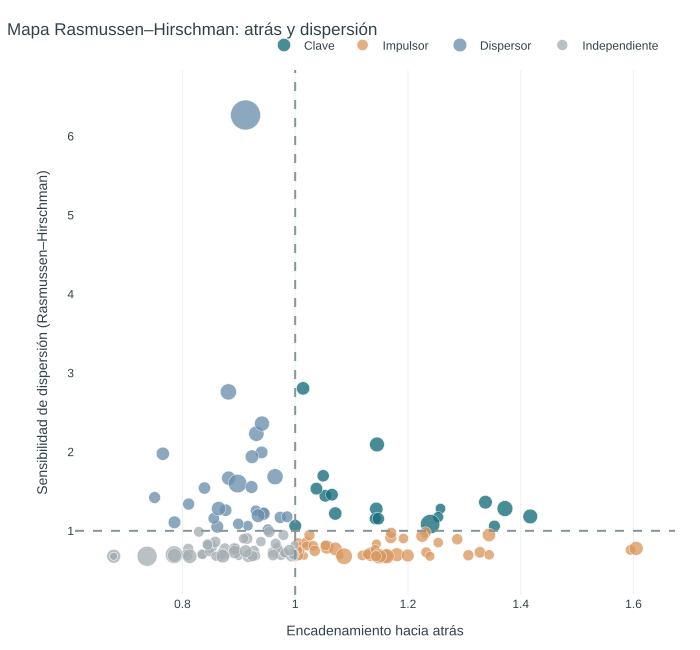

codigo,producto,Multiplicador
P036,Carne y despojos comestibles de aves,2.3667
P035,Carne y despojos comestibles de ganado porcino,2.3518
P016,Café en grano,2.0896
P052,"Azúcar de caña sin refinar y refinada, melaza y los demás azúcares n.c.p.",2.0234
P018,Caucho natural,1.9959
P045,Leche líquida y crema procesada,1.9821
P034,Carne y despojos comestibles de ganado bovino; cueros y pieles de bovino y de otros animales,1.9817
P023,Aves de corral,1.9724
P037,Carne y despojos de otros animales y conservas y preparados de carne,1.9578
P046,Otros productos lácteos n.c.p.,1.9277


codigo,producto,Sensibilidad de dispersión R–H
P102,Servicios de comercio,6.2687
P054,Preparados para alimentación animal,2.8049
P095,"Generación y distribución de energía eléctrica, gas, vapor y aire acondicionado",2.7604
P119,"Otros servicios inmobiliarios, excepto alquiler de vivienda",2.3591
P105,Servicio de transporte de carga por vía terrestre,2.2311
P101,Servicios generales y especializados de construcción,2.0942
P071,"Abonos, fertilizantes y pesticidas",1.9940
P126,Servicios de agencias de empleo y de dotación de recursos humanos,1.9767
P123,"Otros servicios profesionales, científicos y técnicos",1.9393
P132,"Servicios de mantenimiento, reparación e instalación de productos metálicos elaborados, maquinaria y equipo",1.6973


In [5]:
#@title { display-mode: "form" }
conteo_tipos = indicadores["tipo_encadenamiento"].value_counts()
display(
    tarjetas([
        ("Clave", int(conteo_tipos.get("Clave", 0)), "atrás ≥ 1 y dispersión ≥ 1"),
        ("Impulsor", int(conteo_tipos.get("Impulsor", 0)), "atrás ≥ 1 y dispersión < 1"),
        ("Dispersor", int(conteo_tipos.get("Dispersor", 0)), "atrás < 1 y dispersión ≥ 1"),
        ("Independiente", int(conteo_tipos.get("Independiente", 0)), "atrás < 1 y dispersión < 1"),
    ])
)

colores_tipo = {
    "Clave": "#146c7a", "Impulsor": "#d9985f",
    "Dispersor": "#6a8fad", "Independiente": "#a5afb3",
}
fig_link = go.Figure()
for tipo in ["Clave", "Impulsor", "Dispersor", "Independiente"]:
    parte = indicadores[indicadores["tipo_encadenamiento"].eq(tipo)]
    tamanio = 8 + 22 * np.sqrt(parte["produccion_millones_q"].clip(lower=0) / x.max())
    fig_link.add_scatter(
        x=parte["encadenamiento_atras_normalizado"],
        y=parte["encadenamiento_adelante_normalizado"],
        mode="markers",
        name=tipo,
        marker={
            "size": tamanio,
            "color": colores_tipo[tipo],
            "opacity": 0.78,
            "line": {"width": 0.5, "color": "white"},
        },
        customdata=parte[["codigo", "producto", "multiplicador_produccion_domestica", "requerimiento_importacion_total"]],
        hovertemplate=(
            "<b>%{customdata[0]} · %{customdata[1]}</b><br>"
            "Atrás: %{x:.3f}<br>Dispersión R–H: %{y:.3f}<br>"
            "Multiplicador: %{customdata[2]:.3f}<br>"
            "Importación total: %{customdata[3]:.3f}<extra></extra>"
        ),
    )
fig_link.add_vline(x=1, line_dash="dash", line_color="#87959b")
fig_link.add_hline(y=1, line_dash="dash", line_color="#87959b")
estilo_figura(fig_link, "Mapa Rasmussen–Hirschman: atrás y dispersión", altura=650, margen_izq=75)
fig_link.update_xaxes(title="Encadenamiento hacia atrás")
fig_link.update_yaxes(title="Sensibilidad de dispersión (Rasmussen–Hirschman)")
mostrar_figura(fig_link)

top_mult = indicadores.nlargest(10, "multiplicador_produccion_domestica")
top_forward = indicadores.nlargest(10, "encadenamiento_adelante_normalizado")
display(HTML('<div class="mip-two">'))
display(
    tabla_ligera(
        top_mult,
        columnas=["codigo", "producto", "multiplicador_produccion_domestica"],
        nombres={"multiplicador_produccion_domestica": "Multiplicador"},
        formatos={"multiplicador_produccion_domestica": lambda z: fmt_num(z, 4)},
        max_filas=10,
    )
)
display(
    tabla_ligera(
        top_forward,
        columnas=["codigo", "producto", "encadenamiento_adelante_normalizado"],
        nombres={"encadenamiento_adelante_normalizado": "Sensibilidad de dispersión R–H"},
        formatos={"encadenamiento_adelante_normalizado": lambda z: fmt_num(z, 4)},
        max_filas=10,
    )
)
display(HTML('</div>'))

<a id="intensidades"></a>
## 5. Intensidad importada, valor agregado y empleo

Los tres multiplicadores responden a la misma pregunta: ¿qué requerimiento total se asocia con Q1 millón adicional de demanda final doméstica? Las escalas son diferentes y no deben sumarse.

\[
m_m=\mathbf{1}^{\prime}A^mL^d,\qquad
m_v=v^{\prime}L^d,\qquad
m_e=e^{\prime}L^d
\]

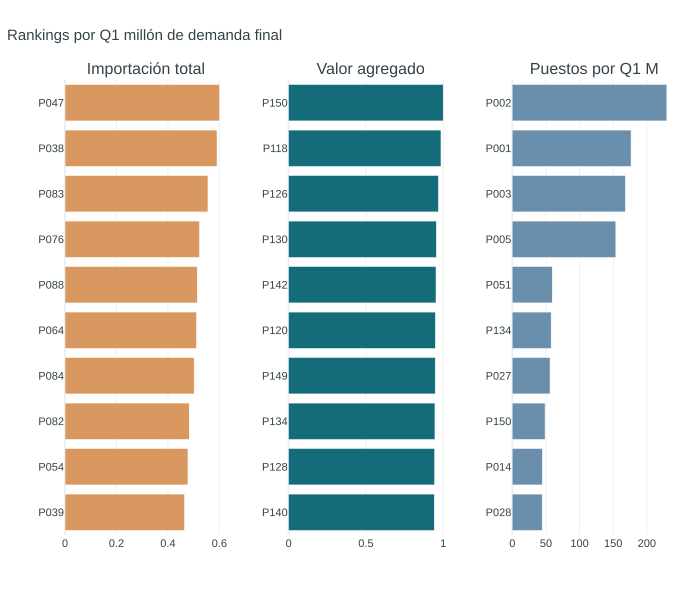

codigo,producto,Importación directa,Importación total,VAB,Puestos/Q1 M
P047,Harina de trigo,0.5577,0.6006,0.3906,1.92
P038,"Pescado congelado, preparado o en conserva y sus productos",0.5616,0.5909,0.3952,2.77
P083,Productos metálicos estructurales y sus partes de hierro o de acero,0.5146,0.5556,0.4321,7.50
P076,Productos de caucho y plástico,0.4759,0.5228,0.4669,4.16
P088,"Maquinaria y aparatos eléctricos, sus partes y piezas",0.4288,0.5141,0.4683,4.20
P064,Pasta de papel y papel,0.4375,0.5110,0.4755,4.71
P084,Otros productos elaborados de metal,0.4700,0.5021,0.4842,7.12
P082,"Métales básicos de hierro y acero, productos primarios de metales preciosos y otros metales no ferrosos",0.4278,0.4828,0.5048,3.51
P054,Preparados para alimentación animal,0.4065,0.4780,0.5192,18.32
P039,"Crustáceos, moluscos y demás invertebrados acuáticos congelados, preparados o en conserva y sus productos",0.3644,0.4644,0.5269,4.06


In [6]:
#@title { display-mode: "form" }
metricas = [
    ("requerimiento_importacion_total", "Importación total", COLORES["importado"]),
    ("multiplicador_valor_agregado", "Valor agregado", COLORES["domestico"]),
    ("multiplicador_empleo_puestos_por_millon", "Puestos por Q1 M", "#6a8fad"),
]
fig_int = make_subplots(
    rows=1, cols=3, horizontal_spacing=0.10,
    subplot_titles=[titulo for _, titulo, _ in metricas],
)
for columna, titulo, color in metricas:
    top = indicadores.nlargest(10, columna).sort_values(columna)
    col = metricas.index((columna, titulo, color)) + 1
    fig_int.add_trace(
        go.Bar(
            y=top["codigo"], x=top[columna], orientation="h",
            marker_color=color, showlegend=False,
            customdata=top[["producto"]],
            hovertemplate="<b>%{y} · %{customdata[0]}</b><br>%{x:.4f}<extra></extra>",
        ),
        row=1, col=col,
    )
fig_int.update_layout(
    template="plotly_white", height=590,
    margin={"l": 65, "r": 25, "t": 80, "b": 55},
    font={"family": "Arial, Helvetica, sans-serif", "size": 11, "color": "#334148"},
    title={"text": "Rankings por Q1 millón de demanda final", "x": 0.01, "xanchor": "left"},
)
fig_int.update_xaxes(showgrid=True, gridcolor="#edf1f2")
fig_int.update_yaxes(showgrid=False)
mostrar_figura(fig_int)

top_import = indicadores.nlargest(12, "requerimiento_importacion_total")
display(
    tabla_ligera(
        top_import,
        columnas=[
            "codigo", "producto", "coeficiente_importacion_directa",
            "requerimiento_importacion_total", "multiplicador_valor_agregado",
            "multiplicador_empleo_puestos_por_millon",
        ],
        nombres={
            "coeficiente_importacion_directa": "Importación directa",
            "requerimiento_importacion_total": "Importación total",
            "multiplicador_valor_agregado": "VAB",
            "multiplicador_empleo_puestos_por_millon": "Puestos/Q1 M",
        },
        formatos={
            "coeficiente_importacion_directa": lambda z: fmt_num(z, 4),
            "requerimiento_importacion_total": lambda z: fmt_num(z, 4),
            "multiplicador_valor_agregado": lambda z: fmt_num(z, 4),
            "multiplicador_empleo_puestos_por_millon": lambda z: fmt_num(z, 2),
        },
        max_filas=12,
    )
)

<a id="simulador"></a>
## 6. Simulador de choque de demanda final

El simulador introduce un aumento exógeno en un solo producto y mantiene constantes precios, tecnología y coeficientes. Producción e importaciones están en millones de quetzales a precios de 2013; los puestos son una asociación mecánica con coeficientes medios. Se excluyen P069, P086, P087, P089, P151 y P152 porque su producción base es cero: en esos casos la diagonal de \(L^d\) es una identidad algebraica sin coeficientes productivos observados.

\[
\Delta x=L^d\Delta y,\qquad
\Delta m=A^m\Delta x,\qquad
\Delta VAB=v^{\prime}\Delta x,\qquad
\Delta E=e^{\prime}\Delta x
\]

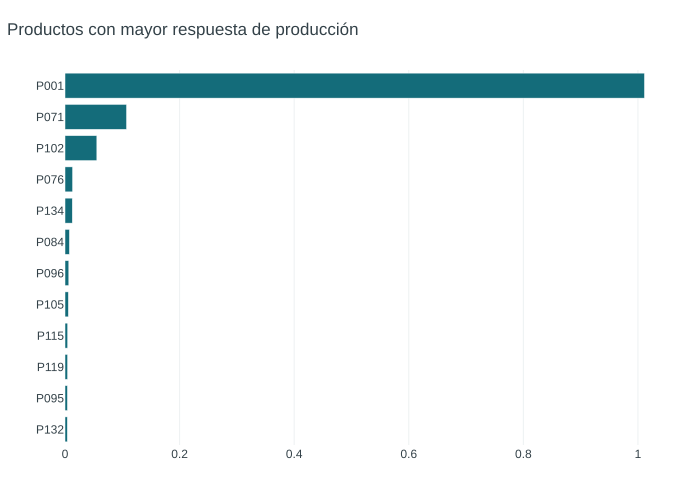

codigo,producto,Producción Q M,Importaciones Q M,VAB Q M,Puestos
P001,Maíz,1.0114,0.0101,0.6916,174.728
P071,"Abonos, fertilizantes y pesticidas",0.1075,0.1440,0.0435,0.066
P102,Servicios de comercio,0.0556,0.0000,0.0396,0.621
P076,Productos de caucho y plástico,0.0133,0.0077,0.0040,0.031
P134,"Servicios de apoyo a la agricultura, caza, silvicultura y pesca",0.0128,0.0000,0.0114,0.729
P084,Otros productos elaborados de metal,0.0078,0.0029,0.0025,0.041
P096,Agua natural y distribución de agua natural,0.0067,0.0000,0.0040,0.069
P105,Servicio de transporte de carga por vía terrestre,0.0059,0.0000,0.0026,0.047
P115,Servicios de Intermediación Financiera Medidos Indirectamente (SIFMI),0.0047,0.0008,0.0031,0.010
P119,"Otros servicios inmobiliarios, excepto alquiler de vivienda",0.0046,0.0000,0.0033,0.018


Output()

In [7]:
#@title { display-mode: "form" }
CODIGO_SIM_INICIAL = "P001"
MONTO_SIM_INICIAL = 1.0
display(HTML('<div class="mip-note"><strong>Vista almacenada.</strong> Choque de Q1 millón en P001 · Maíz.</div>'))
resumen_default, detalle_default, _, _ = vista_simulacion(CODIGO_SIM_INICIAL, MONTO_SIM_INICIAL)

selector_sim = widgets.Dropdown(
    options=[(f"{codigo} · {ETIQUETAS[codigo]}", codigo) for codigo in CODIGOS_SIMULABLES],
    value=CODIGO_SIM_INICIAL,
    description="Producto",
    layout=widgets.Layout(width="760px"),
    style={"description_width": "70px"},
)
monto_sim = widgets.FloatLogSlider(
    value=MONTO_SIM_INICIAL,
    base=10,
    min=-1,
    max=2,
    step=0.1,
    description="Q millones",
    readout_format=".2f",
    continuous_update=False,
    layout=widgets.Layout(width="520px"),
    style={"description_width": "85px"},
)
salida_sim = widgets.Output()

def actualizar_simulador(cambio=None):
    with salida_sim:
        clear_output(wait=True)
        vista_simulacion(selector_sim.value, monto_sim.value)

selector_sim.observe(actualizar_simulador, names="value")
monto_sim.observe(actualizar_simulador, names="value")
display(HTML('<div class="mip-note"><strong>Simulador interactivo.</strong> Seleccione un producto y un monto entre Q0.1 y Q100 millones.</div>'))
display(widgets.VBox([selector_sim, monto_sim]), salida_sim)

<a id="descargas"></a>
## 7. Descargas, QA y guía de uso

Los botones generan CSV directamente desde la memoria del cuaderno. Los enlaces de insumos apuntan a los archivos publicados; no se requiere el libro fuente.

In [8]:
#@title { display-mode: "form" }
resumen_sim_default = pd.DataFrame([resumen_default])
detalle_sim_export = detalle_default.copy()
botones = [
    enlace_descarga_csv(indicadores, "indicadores_io_recalculados_2013.csv", "Descargar indicadores recalculados"),
    enlace_descarga_csv(qa_resumen, "qa_cuaderno_mip_2013.csv", "Descargar QA del cuaderno"),
    enlace_descarga_csv(resumen_sim_default, "simulacion_p001_q1m_resumen.csv", "Descargar resumen de simulación"),
    enlace_descarga_csv(detalle_sim_export, "simulacion_p001_q1m_detalle.csv", "Descargar detalle de simulación"),
]
display(HTML('<div class="mip-wrap"><div class="mip-links">' + "".join(botones) + "</div></div>"))

BASE_RAW = "https://raw.githubusercontent.com/JA-Osorio/mip-guatemala-2013-reproducible/main/"
archivos_publicados = pd.DataFrame([
    ["Productos y etiquetas", "02_resultados_y_diccionario/productos_2013.csv"],
    ["Indicadores IO", "02_resultados_y_diccionario/indicadores_io_2013.csv"],
    ["A doméstica", "02_resultados_y_diccionario/matrices/A_domestica_2013.csv"],
    ["A importada", "02_resultados_y_diccionario/matrices/A_importada_2013.csv"],
    ["Inversa de Leontief doméstica", "02_resultados_y_diccionario/matrices/Leontief_domestica_2013.csv"],
    ["Coeficientes primarios", "02_resultados_y_diccionario/vectores/coeficientes_primarios_2013.csv"],
    ["Producción y utilización", "02_resultados_y_diccionario/vectores/produccion_y_utilizacion_2013.csv"],
    ["Balances por producto", "05_verificacion/balances_por_producto.csv"],
], columns=["contenido", "ruta"])
enlaces = "".join(
    f'<a class="mip-btn" href="{BASE_RAW}{_html.escape(ruta)}">{_html.escape(contenido)}</a>'
    for contenido, ruta in archivos_publicados.itertuples(index=False)
)
display(HTML('<div class="mip-note"><strong>CSV publicados usados por el visor.</strong></div><div class="mip-wrap"><div class="mip-links">' + enlaces + "</div></div>"))
display(
    tabla_ligera(
        qa_resumen,
        nombres={"control": "Control", "valor": "Valor", "tolerancia": "Tolerancia", "cumple": "Estado"},
        formatos={"valor": lambda z: fmt_num(z, 4) if isinstance(z, (float, np.floating)) else str(z)},
        max_filas=10,
    )
)

Control,Valor,Tolerancia,Estado
Productos y orden NPG,152.0000,152,APROBADO
Inversa doméstica: residuo máximo,0.0000,<= 1e-10,APROBADO
A total = A doméstica + A importada,0.0000,<= 1e-12,APROBADO
Balance final: residuo máximo,0.0000,<= 1e-10,APROBADO
Indicadores recalculados vs publicados,0.0000,<= 1e-12,APROBADO
Controles obligatorios aprobados,21.0000,21,APROBADO


### Cómo reutilizar la MIP en una investigación futura

1. **Defina el objeto del choque.** La demanda final adicional debe tener la misma unidad de la MIP: millones de quetzales a precios de 2013.
2. **Seleccione el producto correcto.** Use el explorador para comprobar su código, insumos directos, contenido importado y multiplicadores antes de simular.
3. **Separe circuitos.** \(L^d\) calcula producción doméstica. \(A^mL^d\) calcula insumos intermedios importados asociados; no los sume a la producción nacional.
4. **Interprete cada multiplicador en su unidad.** Producción, importaciones y VAB están en Q millones; empleo está en puestos asociados por Q1 millón.
5. **Documente la transformación del choque.** Si la cifra original pertenece a otro año, moneda o valoración, registre deflactor, tipo de cambio y concordancia.
6. **Ejecute los controles.** No use resultados si falla la inversa, la descomposición de \(A\), el balance final o la comparación de indicadores.
7. **Exporte la evidencia.** Descargue indicadores, QA y detalle de simulación para conservar la trazabilidad de cada análisis.

### Límites del simulador

- Es un modelo lineal y estático: no incluye precios, restricciones de capacidad, sustitución ni cambio tecnológico.
- La MIP es producto por producto y usa una tecnología promedio de 2013.
- Los coeficientes laborales son promedios; el resultado no representa empleo neto, vacantes ni duración de puestos.
- Los productos P069, P086, P087, P089, P151 y P152 permanecen visibles para auditoría, pero no se simulan porque su producción base es cero.
- Para choques grandes, escenarios prospectivos o otra clasificación, construya sensibilidades y documente una concordancia explícita.

<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;margin-top:28px;padding:18px 0;border-top:1px solid #dfe6e9;color:#748087;font-size:12px">Fin del visor · Todos los cálculos parten de CSV publicados · Código plegado · Salidas guardadas</div>